<a href="https://colab.research.google.com/github/Afnankh00/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediction of Product Sales**


*   Author : Afnan Adel khattab



# **Project Overview**

Clean and prepare the sales prediction dataset for machine learning analysis by addressing data quality issues including missing values, inconsistent categories, and data type validation.


# **Load and Inspect Data**

In [4]:
# Import required packages
import pandas as pd
import numpy as np
import missingno as msno
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the sales prediction dataset
# Update this path to match your file location
fpath = '/content/drive/MyDrive/Course 1/Week 1/sales_predictions_2023.csv'
df = pd.read_csv(fpath)

Mounted at /content/drive


In [ ]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# **Exploratory Data Analysis**

In [5]:
# Preview the data
print("First 5 rows:")
df.head()

First 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
print("\nLast 5 rows:")
df.tail()


Last 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [ ]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# **Feature Inspection**

In [ ]:
print("1) DATASET SIZE")
print("*" * 50)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"DataFrame shape: {df.shape}")
print("*" * 50)
# print the data types
print("2) DATA TYPES")
print("*" * 50)
print(df.dtypes)
# check the no. duplicates rows
print("*" * 50)
print("3) DUPLICATE CHECK")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

1) DATASET SIZE
**************************************************
Number of rows: 8523
Number of columns: 12
DataFrame shape: (8523, 12)
**************************************************
2) DATA TYPES
**************************************************
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object
**************************************************
3) DUPLICATE CHECK
Number of duplicate rows: 0


In [ ]:
print("\nPercentage of missing values per column:")
missing_pct = round((df.isnull().sum() / len(df)) * 100, 2)
print(missing_pct[missing_pct > 0])


Percentage of missing values per column:
Item_Weight    17.17
Outlet_Size    28.28
dtype: float64


# **Data Cleaning**
# Visualize the Data

<Axes: >

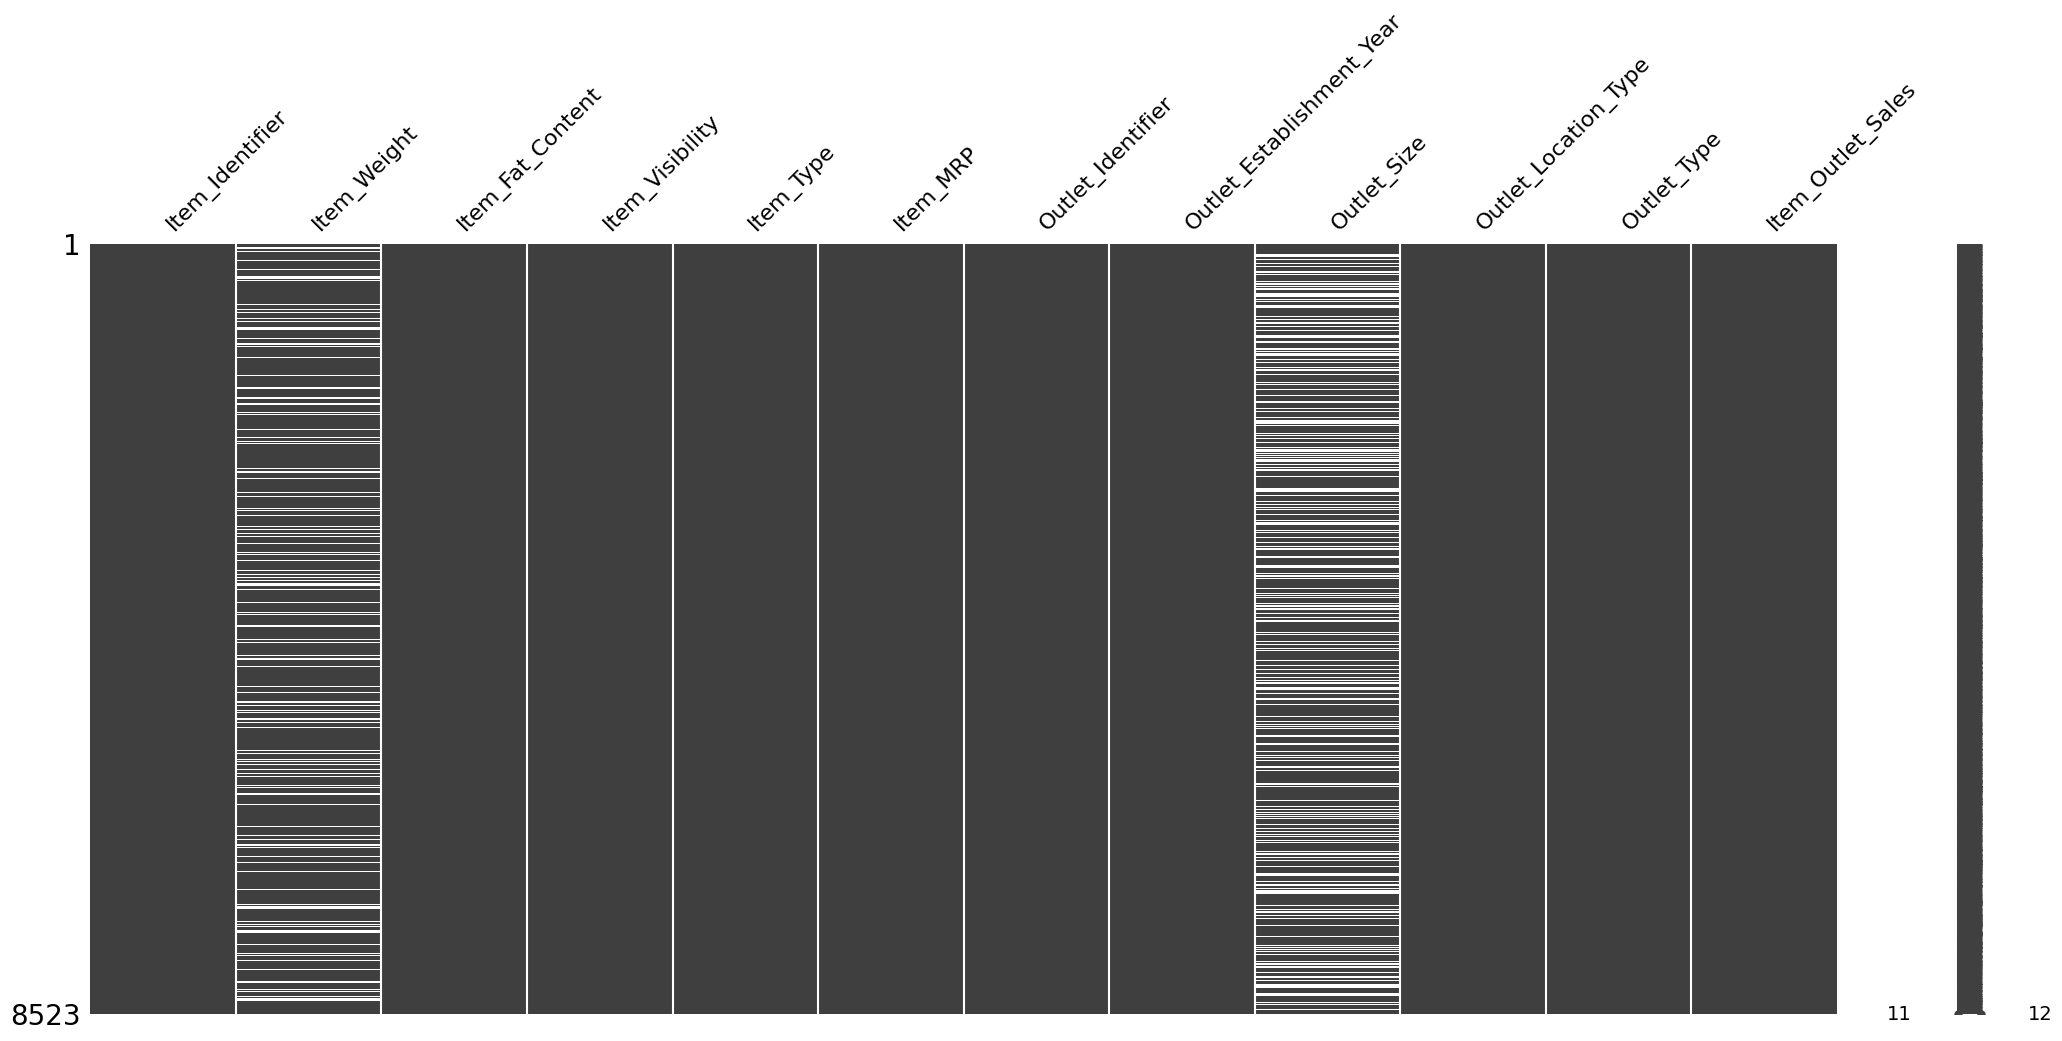

In [ ]:
msno.matrix(df)

In [6]:
# Get lists of categorical and numeric columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")
print(f"Numeric columns: {num_cols}")


Categorical columns: ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
Numeric columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']


In [7]:
# Fill categorical columns with 'MISSING'
df[cat_cols] = df[cat_cols].fillna('MISSING')
print("\nFilled categorical columns with 'MISSING'")

# Fill numeric columns with -1
df[num_cols] = df[num_cols].fillna(-1)
print("Filled numeric columns with -1")


Filled categorical columns with 'MISSING'
Filled numeric columns with -1


In [8]:
print("\nMissing values after addressing:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values after addressing:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Total missing values: 0


<Axes: >

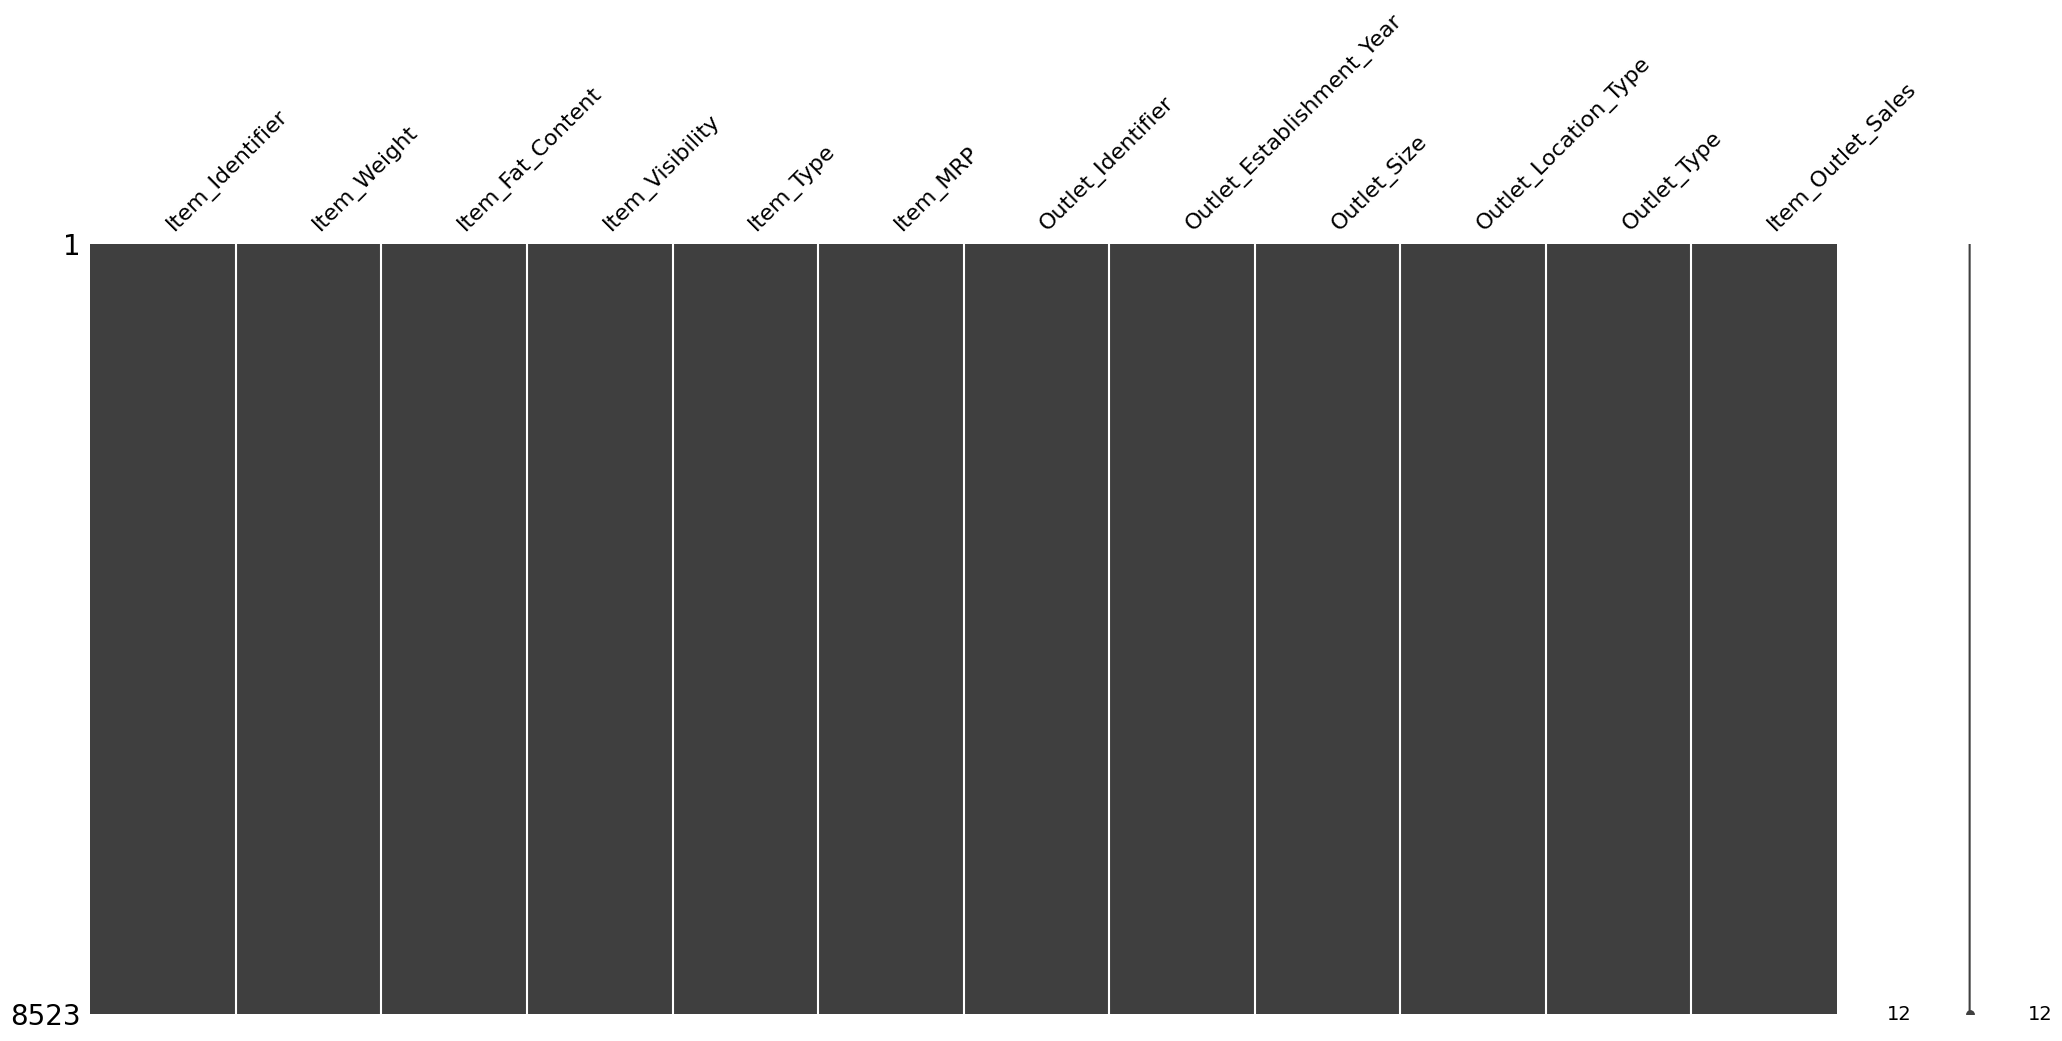

In [9]:
# Confirm with missingno
msno.matrix(df)

In [10]:
print("\nValue counts BEFORE fixing inconsistencies:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 50)



Value counts BEFORE fixing inconsistencies:

Item_Identifier:
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
--------------------------------------------------

Item_Fat_Content:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------

Item_Type:
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Nam

In [11]:
# Fix Item_Fat_Content inconsistencies
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
    'Low fat': 'Low Fat'
})

In [12]:
# Check value counts AFTER fixing
print("Value counts for Item_Fat_Content AFTER fixing:\n")
print(df['Item_Fat_Content'].value_counts())

Value counts for Item_Fat_Content AFTER fixing:

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [13]:
# Summary statistics for numerical columns
# Get list of numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [14]:
print(df[num_cols].describe())

       Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  8523.000000      8523.000000  8523.000000                8523.000000   
mean     10.478936         0.066132   140.992782                1997.831867   
std       6.720742         0.051598    62.275067                   8.371760   
min      -1.000000         0.000000    31.290000                1985.000000   
25%       6.650000         0.026989    93.826500                1987.000000   
50%      11.000000         0.053931   143.012800                1999.000000   
75%      16.000000         0.094585   185.643700                2004.000000   
max      21.350000         0.328391   266.888400                2009.000000   

       Item_Outlet_Sales  
count        8523.000000  
mean         2181.288914  
std          1706.499616  
min            33.290000  
25%           834.247400  
50%          1794.331000  
75%          3101.296400  
max         13086.964800  


In [15]:
print("MIN, MAX, MEAN for each numeric column:\n")
for col in num_cols:
    print(f"\n{col}:")
    print(f"  Min:  {round(df[col].min(), 2)}")
    print(f"  Max:  {round(df[col].max(), 2)}")
    print(f"  Mean: {round(df[col].mean(), 2)}")

MIN, MAX, MEAN for each numeric column:


Item_Weight:
  Min:  -1.0
  Max:  21.35
  Mean: 10.48

Item_Visibility:
  Min:  0.0
  Max:  0.33
  Mean: 0.07

Item_MRP:
  Min:  31.29
  Max:  266.89
  Mean: 140.99

Outlet_Establishment_Year:
  Min:  1985
  Max:  2009
  Mean: 1997.83

Item_Outlet_Sales:
  Min:  33.29
  Max:  13086.96
  Mean: 2181.29


# **Data Visulazation**

In [1]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 1. HISTOGRAMS - Distribution of Numerical Features


<Figure size 1500x1000 with 0 Axes>

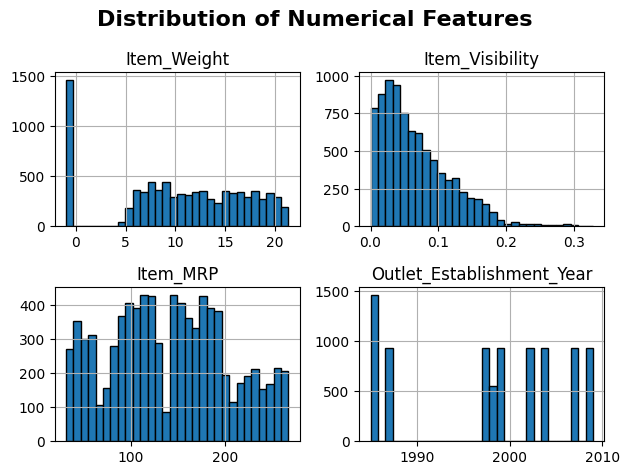

In [19]:
plot_df = df.copy()
plt.figure(figsize=(15, 10))
plot_df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']].hist(
    bins=30,
    edgecolor='black', )
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# BOXPLOTS - Statistical Summaries of Numerical Features

/tmp/ipykernel_186/1340695625.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(df['Item_Weight'].dropna(), vert=True, patch_artist=True, labels=['Item Weight'])
/tmp/ipykernel_186/1340695625.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(df['Item_Visibility'], vert=True, patch_artist=True, labels=['Item Visibility'])
/tmp/ipykernel_186/1340695625.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot(df['Item_MRP'], vert=True, patch_artist=True, labels=['Item MRP'])
/tmp/ipykernel_186/1340695625.py:20: MatplotlibDeprecationWarning: The 'labels' parameter 

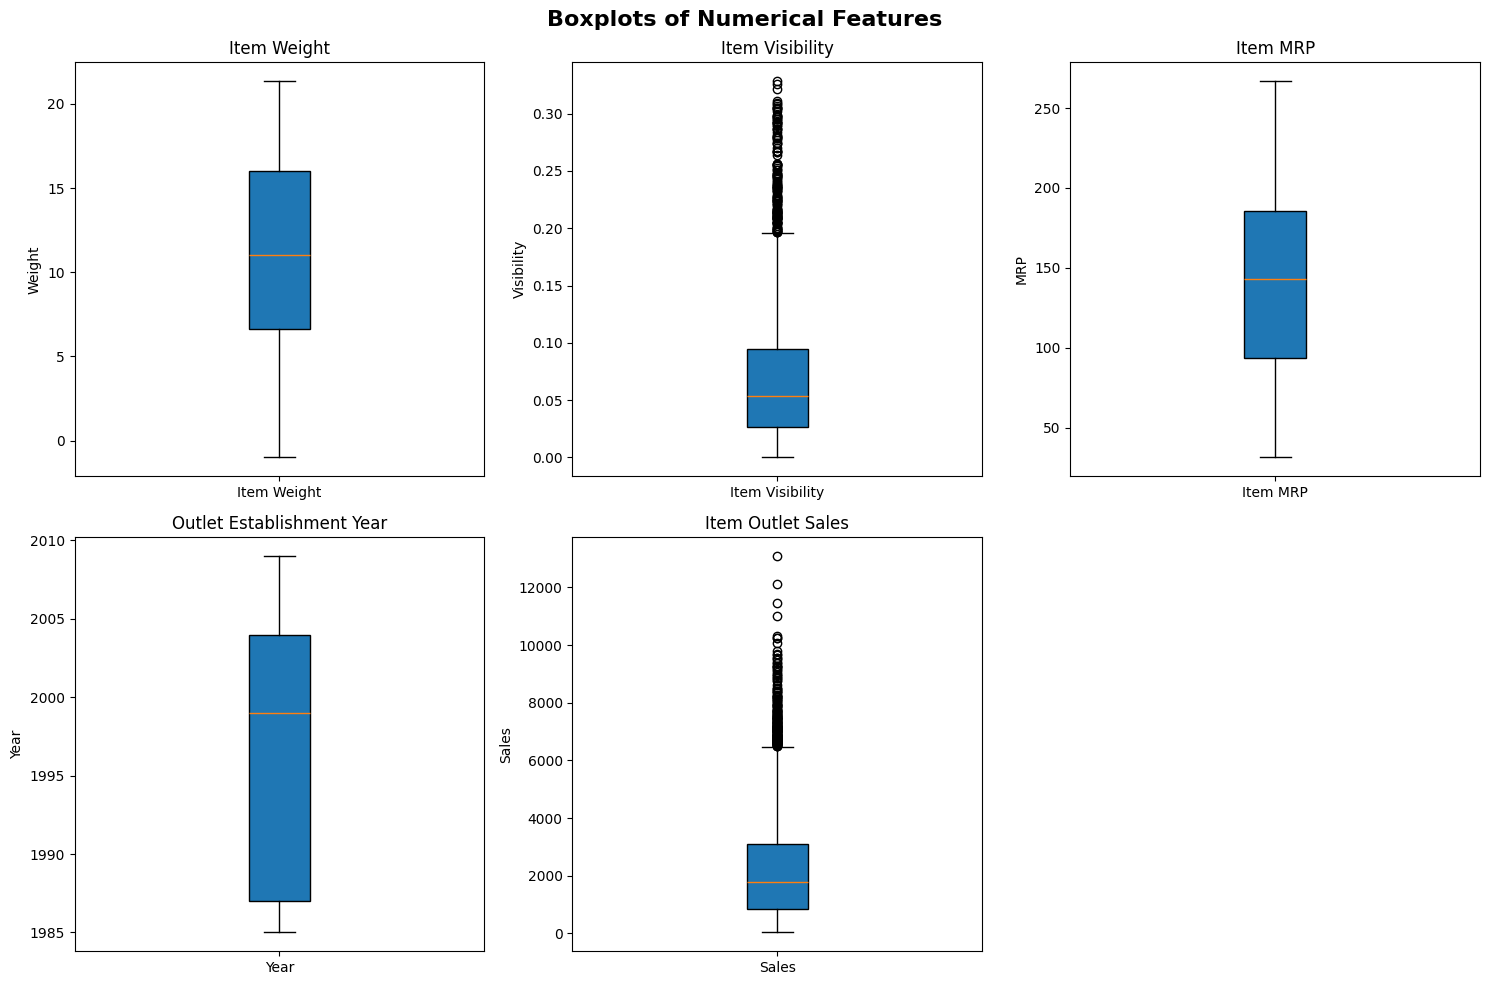

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots of Numerical Features', fontsize=16, fontweight='bold')

# Item_Weight
axes[0, 0].boxplot(df['Item_Weight'].dropna(), vert=True, patch_artist=True, labels=['Item Weight'])
axes[0, 0].set_title('Item Weight')
axes[0, 0].set_ylabel('Weight')

# Item_Visibility
axes[0, 1].boxplot(df['Item_Visibility'], vert=True, patch_artist=True, labels=['Item Visibility'])
axes[0, 1].set_title('Item Visibility')
axes[0, 1].set_ylabel('Visibility')


axes[0, 2].boxplot(df['Item_MRP'], vert=True, patch_artist=True, labels=['Item MRP'])
axes[0, 2].set_title('Item MRP')
axes[0, 2].set_ylabel('MRP')

# Outlet_Establishment_Year
axes[1, 0].boxplot(df['Outlet_Establishment_Year'], vert=True, patch_artist=True, labels=['Year'])
axes[1, 0].set_title('Outlet Establishment Year')
axes[1, 0].set_ylabel('Year')

# Item_Outlet_Sales
axes[1, 1].boxplot(df['Item_Outlet_Sales'], vert=True, patch_artist=True, labels=['Sales'])
axes[1, 1].set_title('Item Outlet Sales')
axes[1, 1].set_ylabel('Sales')

# Hide the empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# COUNTPLOTS - Frequency of Categorical Features

/tmp/ipykernel_186/3344852690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Fat_Content', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_186/3344852690.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Type', ax=axes[0, 1], palette='Set3', order=top_item_types)
/tmp/ipykernel_186/3344852690.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outlet_Size', ax=axes[1, 0], palette='Set1')
/tmp/ipykernel_186/3344852690.py:21: FutureWarning: 

Passing `palette` without assigning `hue` i

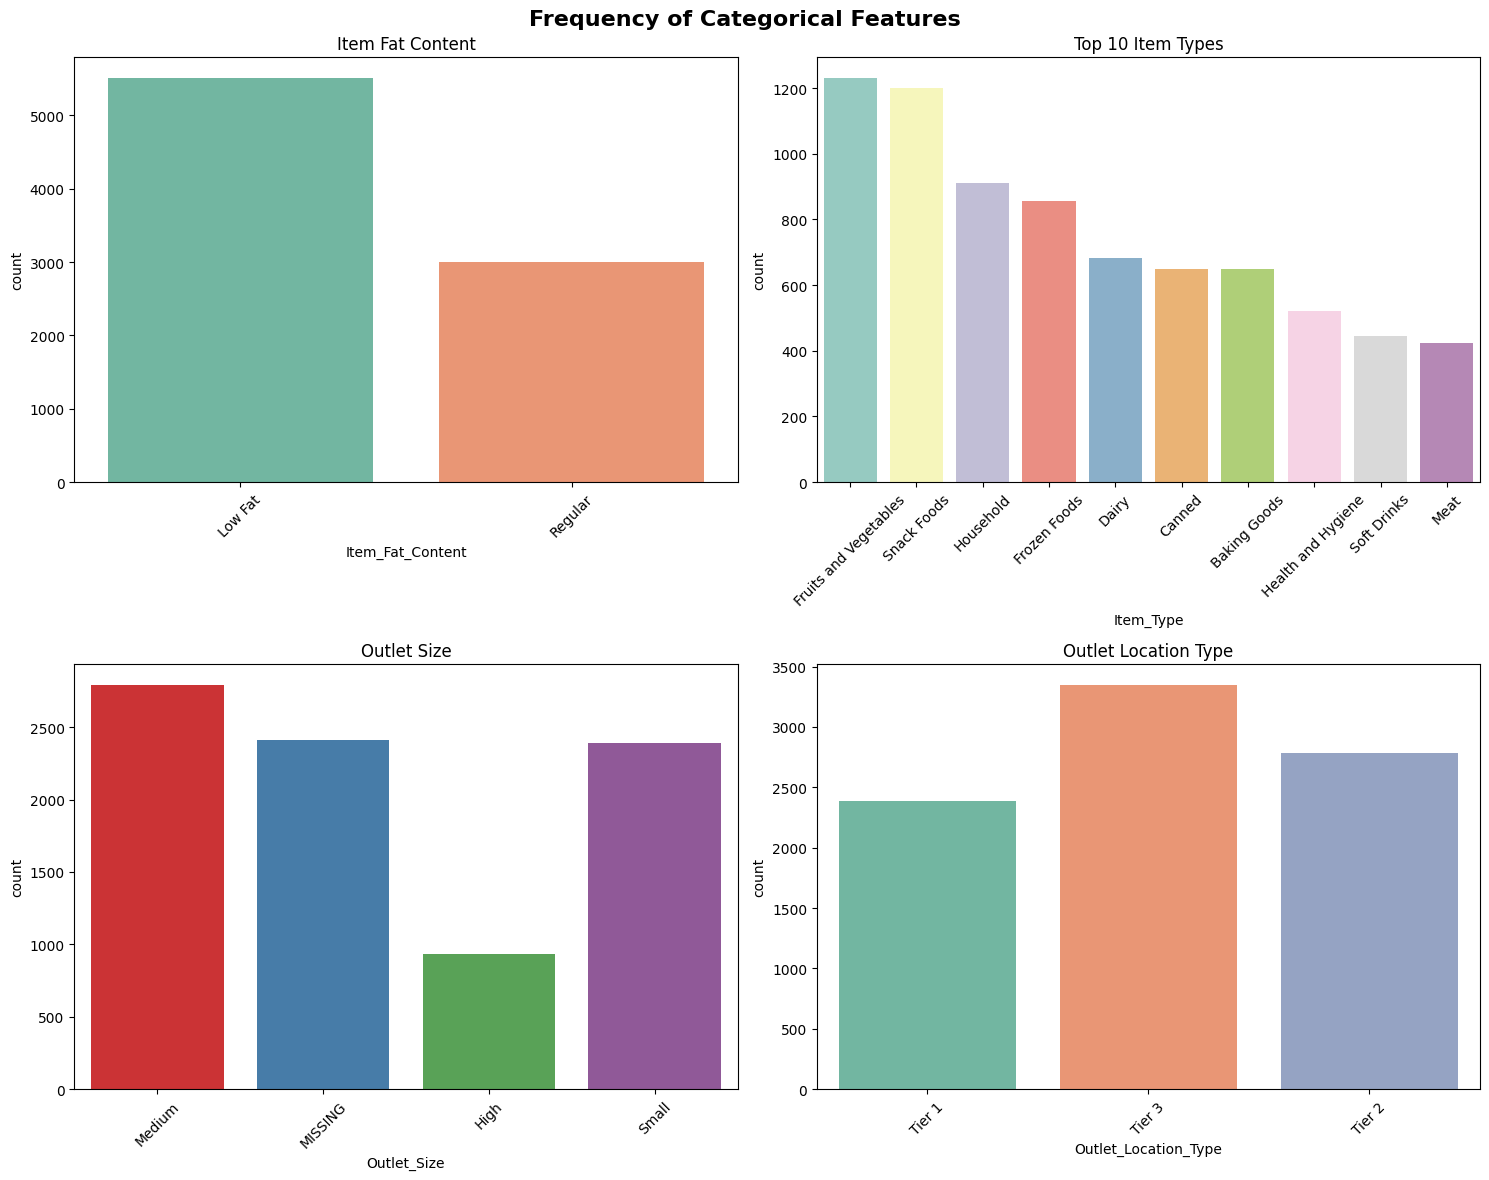

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Frequency of Categorical Features', fontsize=16, fontweight='bold')

# Item_Fat_Content
sns.countplot(data=df, x='Item_Fat_Content', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Item Fat Content')
axes[0, 0].tick_params(axis='x', rotation=45)

# Item_Type (Top 10 only to avoid clutter)
top_item_types = df['Item_Type'].value_counts().nlargest(10).index
sns.countplot(data=df, x='Item_Type', ax=axes[0, 1], palette='Set3', order=top_item_types)
axes[0, 1].set_title('Top 10 Item Types')
axes[0, 1].tick_params(axis='x', rotation=45)

# Outlet_Size
sns.countplot(data=df, x='Outlet_Size', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Outlet Size')
axes[1, 0].tick_params(axis='x', rotation=45)

# Outlet_Location_Type
sns.countplot(data=df, x='Outlet_Location_Type', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Outlet Location Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 # HEATMAP - Correlation between Features

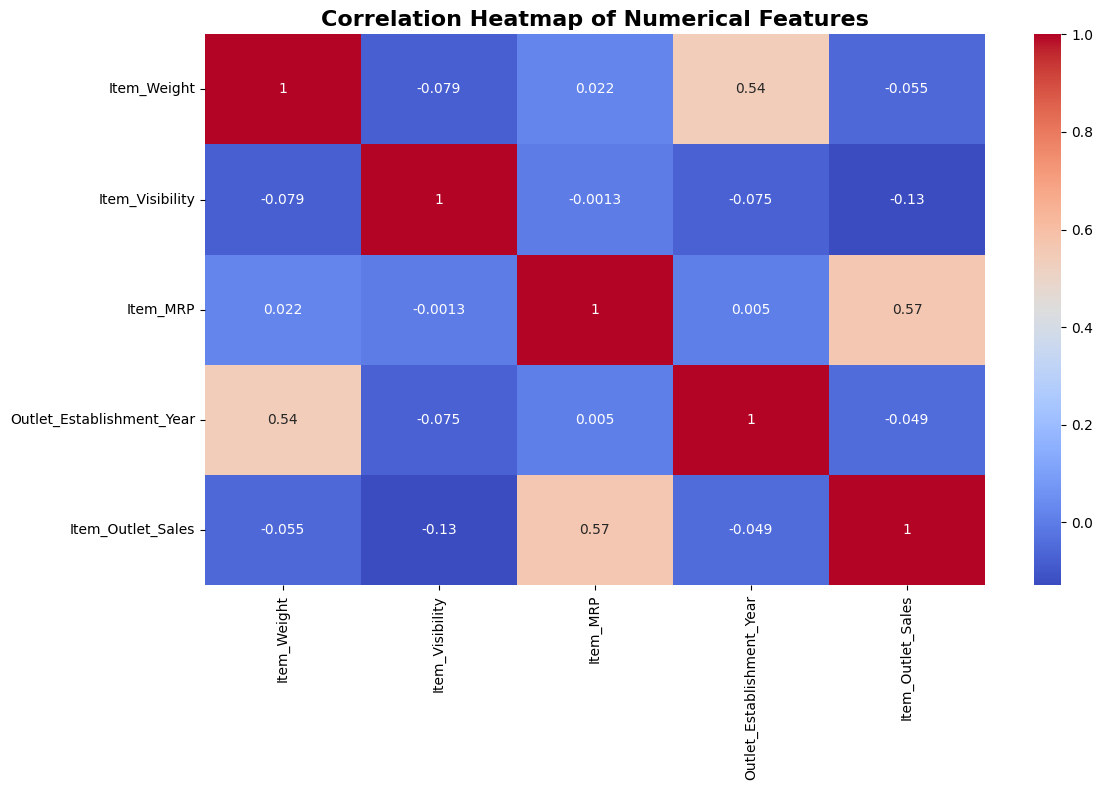

In [27]:
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
numerical_df = df[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']]
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()